# Notebook 04: Content-Based Recommendation System
### Hybrid E-Commerce Recommendation System — H&M Personalized Fashion Recommendations

**Scope of this notebook:** build a complete content-based recommendation engine using the
artifacts saved by the Step 3 preprocessing notebook. **No collaborative filtering or hybrid
logic is implemented here** — that's Notebook 05 and beyond.


---
## Part A: Introduction — What is Content-Based Filtering?

**Core idea:** recommend items that are *similar in content* to items a user has already shown
interest in — similar in the sense of shared attributes (category, description, color, etc.),
not similar in the sense of "other users who liked X also liked Y" (that's collaborative filtering).

**How it works, intuitively:** every product gets turned into a "fingerprint" made of its text
and category information. Two products with similar fingerprints (e.g., both are black running
shoes with similar descriptions) get a high similarity score. When a user has interacted with
Product A, we recommend other products whose fingerprints are closest to A's.

**When is it useful?**
- **New/cold-start products** — a product added to the catalog yesterday has zero purchase
  history, so collaborative filtering has nothing to work with. But it *does* have a
  name, category, and description from day one — so content-based filtering can recommend it
  immediately.
- **Users with very sparse history** — a customer who bought one item still gives us *something*
  to work with (that item's content), even though there's not enough interaction data for
  meaningful collaborative filtering.
- **Explainability** — "recommended because it's a similar dress in the same department" is a
  natural, human-understandable explanation, unlike a collaborative filtering latent factor.

**Advantages:**
- No cold-start problem for new items
- Recommendations are naturally explainable
- Works even with very few users

**Limitations:**
- Cannot capture *behavioral* patterns (e.g., "people who buy running shoes also tend to buy
  water bottles" — items with completely different content, but shared purchase context)
- Tends to recommend items that are all very similar to each other (echo-chamber effect,
  addressed under Diversity in Part I)
- Quality depends entirely on how good the text/category metadata is

**Content-Based vs. Collaborative Filtering — the core distinction:**

| | Content-Based | Collaborative Filtering |
|---|---|---|
| Signal used | Item attributes (text, category) | User-item interaction patterns |
| Cold-start items | Handles well | Struggles (no interactions yet) |
| Cold-start users | Still struggles a little, but has *some* fallback via item content once they've interacted with 1 item | Struggles badly (no interaction history) |
| Explainability | High (shared attributes) | Lower (latent factors) |
| Discovers non-obvious patterns | No — limited to stated attributes | Yes — can surprise you |

This is precisely why the final system will be **hybrid**: content-based fills the gaps that
collaborative filtering can't.


---
## Part B: Load Processed Data

We only need two files here — `content_features.csv` (the cleaned text corpus) and
`processed_articles.csv` (full product metadata, for displaying human-readable results later).
Nothing else from Step 3 is needed for content-based filtering itself.


**Note on file location:** since Colab sessions are ephemeral, mount Google Drive if that's
where your `processed_data/` folder was saved in Step 3. If the files are already present locally
(e.g., same session), this cell will just use them directly.


In [3]:
import os
from google.colab import drive

drive.mount('/content/drive')

PROCESSED_DATA_DIR = "/content/drive/MyDrive/hm_recsys/processed_data"
print("Using data directory:", PROCESSED_DATA_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using data directory: /content/drive/MyDrive/hm_recsys/processed_data


In [4]:
import pandas as pd

content_features = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "content_features.csv"))
processed_articles = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "processed_articles.csv"))

print("content_features shape:", content_features.shape)
print("processed_articles shape:", processed_articles.shape)


content_features shape: (105542, 2)
processed_articles shape: (105542, 27)


**B.1 Verify shape, missing values, duplicates, sample records**

In [5]:
def verify_dataset(df, name):
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print("Shape:", df.shape)
    print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
    print("Duplicate rows:", df.duplicated().sum())
    print("\nSample records:")
    display(df.head(3))

verify_dataset(content_features, "content_features")
verify_dataset(processed_articles, "processed_articles")



content_features
Shape: (105542, 2)
Missing values:
 Series([], dtype: int64)
Duplicate rows: 0

Sample records:


,article_id,combined_features
0,108775015,strap top vest top garment upper body jersey b...
1,108775044,strap top vest top garment upper body jersey b...
2,108775051,strap top 1 vest top garment upper body jersey...



processed_articles
Shape: (105542, 27)
Missing values:
 detail_desc    416
dtype: int64
Duplicate rows: 0

Sample records:


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc,combined_features_raw,combined_features
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,Strap top Vest top Garment Upper body Jersey B...,strap top vest top garment upper body jersey b...
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,Strap top Vest top Garment Upper body Jersey B...,strap top vest top garment upper body jersey b...
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,Strap top (1) Vest top Garment Upper body Jers...,strap top 1 vest top garment upper body jersey...


---
## Part C: Build Product Corpus

The `combined_features` column (built in Step 3) is our text corpus — one string per product,
combining product name, category, department, garment group, colour, and description.


In [6]:
corpus = content_features["combined_features"].fillna("")

# Check for empty text — a product with no usable text will get a near-zero TF-IDF vector,
# meaning it won't meaningfully match anything. Worth knowing how many exist before vectorizing.
n_empty = (corpus.str.len() == 0).sum()
avg_len = corpus.apply(lambda x: len(x.split())).mean()

print(f"Total products in corpus: {len(corpus):,}")
print(f"Products with empty text: {n_empty:,}")
print(f"Average word count per product: {avg_len:.1f}")


Total products in corpus: 105,542
Products with empty text: 0
Average word count per product: 36.9


**C.1 Vocabulary sample — most common words in the raw corpus (before TF-IDF weighting)**

In [7]:
from collections import Counter

all_words = " ".join(corpus.sample(min(20000, len(corpus)), random_state=42)).split()
most_common = Counter(all_words).most_common(20)

print("Most frequent words in a 20K-product sample:")
for word, count in most_common:
    print(f"  {word}: {count}")


Most frequent words in a 20K-product sample:
  and: 31280
  a: 28882
  with: 28568
  the: 25784
  in: 20876
  jersey: 16100
  at: 15285
  body: 14815
  garment: 14632
  top: 8187
  upper: 8182
  fancy: 7100
  back: 6937
  front: 6906
  soft: 6762
  cotton: 6588
  waist: 6429
  dress: 6020
  trousers: 5681
  sleeves: 5344


**Why this corpus is suitable for TF-IDF:** it's genuine natural-language text (not hashed
codes, unlike some e-commerce datasets), reasonably consistent in length, and low in empty
entries. The most-common-words check above also tells us what generic filler words (like
"cotton", "black" if extremely frequent) TF-IDF will naturally down-weight, since TF-IDF
specifically discounts words that appear in *most* documents — exactly the words a plain word
count would over-value.


---
## Part D: TF-IDF Vectorization

**Term Frequency (TF):** how often a word appears in a given product's text, relative to that
product's total word count. A word appearing 3 times in a 10-word description has a higher TF
than the same word appearing 3 times in a 100-word description.

**Inverse Document Frequency (IDF):** down-weights words that appear across *many* products.
"Cotton" appears in thousands of product descriptions, so it's not distinctive — it gets a low
IDF weight. A rarer word like "sequined" appears in far fewer products, so it gets a high IDF
weight, since it *is* distinctive.

**Formula:**

`TF-IDF(word, doc) = TF(word, doc) × IDF(word)`

where `IDF(word) = log( N / (1 + df(word)) )`, with `N` = total number of products and `df(word)`
= number of products containing that word. The `+1` avoids division by zero.

**Why TF-IDF beats a plain Count Vectorizer:** a Count Vectorizer would score "cotton" as
important simply because it appears often — but if *every* product mentions cotton, it tells us
nothing about which products are actually similar to each other. TF-IDF corrects for this by
weighting down universally common words and weighting up rare, distinguishing words — exactly
the words that actually indicate two products are alike.


**D.1 Experiment with different TF-IDF configurations**

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

configs = [
    {"max_features": 5000,  "min_df": 2, "max_df": 0.8, "ngram_range": (1, 1)},
    {"max_features": 10000, "min_df": 2, "max_df": 0.8, "ngram_range": (1, 2)},
    {"max_features": 15000, "min_df": 3, "max_df": 0.7, "ngram_range": (1, 2)},
]

results = []
for cfg in configs:
    vec = TfidfVectorizer(**cfg, stop_words="english")
    matrix = vec.fit_transform(corpus)
    density = matrix.nnz / (matrix.shape[0] * matrix.shape[1])
    results.append({
        "config": cfg,
        "vocab_size": len(vec.vocabulary_),
        "matrix_shape": matrix.shape,
        "density_pct": density * 100
    })

for r in results:
    print(r)


{'config': {'max_features': 5000, 'min_df': 2, 'max_df': 0.8, 'ngram_range': (1, 1)}, 'vocab_size': 5000, 'matrix_shape': (105542, 5000), 'density_pct': 0.4429794773644615}
{'config': {'max_features': 10000, 'min_df': 2, 'max_df': 0.8, 'ngram_range': (1, 2)}, 'vocab_size': 10000, 'matrix_shape': (105542, 10000), 'density_pct': 0.42346212882075385}
{'config': {'max_features': 15000, 'min_df': 3, 'max_df': 0.7, 'ngram_range': (1, 2)}, 'vocab_size': 15000, 'matrix_shape': (105542, 15000), 'density_pct': 0.27972143791097387}


**D.2 Chosen configuration**

We select `max_features=10000, min_df=2, max_df=0.8, ngram_range=(1, 2)` — a balance between
vocabulary richness (bigrams like "running shoes" capture more meaning than unigrams alone) and
matrix size (10K features keeps the matrix manageable at our scale of ~105K products).


In [9]:
FINAL_TFIDF_CONFIG = {"max_features": 10000, "min_df": 2, "max_df": 0.8, "ngram_range": (1, 2)}

tfidf_vectorizer = TfidfVectorizer(**FINAL_TFIDF_CONFIG, stop_words="english")
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

vocab_size = len(tfidf_vectorizer.vocabulary_)
density = tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])

print(f"Vocabulary size: {vocab_size:,}")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Matrix density: {density*100:.4f}% (sparse, as expected — most products don't share most words)")


Vocabulary size: 10,000
TF-IDF matrix shape: (105542, 10000)
Matrix density: 0.4235% (sparse, as expected — most products don't share most words)


**D.3 Save the vectorizer and matrix**

In [10]:
import pickle
from scipy.sparse import save_npz

os.makedirs("cb_artifacts", exist_ok=True)

with open("cb_artifacts/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

save_npz("cb_artifacts/tfidf_matrix.npz", tfidf_matrix)

print("Saved: cb_artifacts/tfidf_vectorizer.pkl")
print("Saved: cb_artifacts/tfidf_matrix.npz")


Saved: cb_artifacts/tfidf_vectorizer.pkl
Saved: cb_artifacts/tfidf_matrix.npz


---
## Part E: Cosine Similarity

**Dot product:** for two vectors, the dot product measures how much they "point in the same
direction" — larger when both vectors have high values in the same positions (i.e., share
important words).

**Cosine similarity:** the dot product of two vectors, normalized by their magnitudes:

`cosine_similarity(A, B) = (A · B) / (||A|| × ||B||)`

This returns a value between 0 (completely dissimilar) and 1 (identical direction).

**Why cosine, not raw dot product or Euclidean distance:** product descriptions vary a lot in
length. A long, detailed description will have a naturally larger raw dot product with anything,
simply from having more non-zero terms — not because it's actually more similar. Cosine
similarity normalizes this away, comparing the *direction* (topic/content) of the vectors rather
than their raw magnitude (length).

**Memory reality check:** a full item-item similarity matrix would be ~105,000 × 105,000 — over
11 billion cells. Even as float32, that's roughly **44GB** — completely infeasible to store in
Colab's RAM. So instead of precomputing and storing the full matrix, we **compute similarity
on demand**: for a given product, we compute its similarity against all other products only when
a recommendation is requested — a single row of the matrix (105K similarities) is trivial to
compute and hold in memory, unlike all 105K rows at once.


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similarities_for_product(product_index, tfidf_matrix):
    """Compute cosine similarity between ONE product and all others, on demand.
    This avoids ever materializing the full NxN similarity matrix."""
    product_vector = tfidf_matrix[product_index]
    similarities = cosine_similarity(product_vector, tfidf_matrix).flatten()
    return similarities

# Quick demonstration on one product
sample_similarities = get_similarities_for_product(0, tfidf_matrix)
print("Similarity vector shape:", sample_similarities.shape)
print("Self-similarity (should be ~1.0):", sample_similarities[0])


Similarity vector shape: (105542,)
Self-similarity (should be ~1.0): 0.9999999999999999


---
## Part F: Recommendation Engine

Reusable functions for generating recommendations. Each returns product name, similarity score,
category, department, and colour for easy interpretation.


In [12]:
# Build lookup structures once, reused by all functions below
article_ids = content_features["article_id"].values
id_to_index = {aid: idx for idx, aid in enumerate(article_ids)}

articles_lookup = processed_articles.set_index("article_id")

def _format_results(indices, scores, exclude_index=None):
    """Shared helper: assemble a results DataFrame from index positions and their scores."""
    rows = []
    for idx, score in zip(indices, scores):
        if idx == exclude_index:
            continue
        aid = article_ids[idx]
        if aid not in articles_lookup.index:
            continue
        meta = articles_lookup.loc[aid]
        rows.append({
            "article_id": aid,
            "product_name": meta.get("prod_name", ""),
            "similarity_score": round(float(score), 4),
            "category": meta.get("product_group_name", ""),
            "department": meta.get("department_name", ""),
            "colour": meta.get("colour_group_name", "")
        })
    return pd.DataFrame(rows)

def recommend_similar_products(product_id, top_n=10):
    """Given an article_id, return the top_n most similar products by content."""
    if product_id not in id_to_index:
        raise ValueError(f"product_id {product_id} not found in the product corpus")

    idx = id_to_index[product_id]
    similarities = get_similarities_for_product(idx, tfidf_matrix)

    # argsort descending, skip the product itself (always most similar to itself)
    top_indices = similarities.argsort()[::-1][:top_n + 1]
    top_scores = similarities[top_indices]

    return _format_results(top_indices, top_scores, exclude_index=idx)

def recommend_by_product_name(product_name, top_n=10):
    """Look up a product by (partial, case-insensitive) name match, then recommend similar items."""
    matches = processed_articles[
        processed_articles["prod_name"].str.contains(product_name, case=False, na=False)
    ]
    if matches.empty:
        raise ValueError(f"No product found matching name: {product_name}")

    matched_id = matches.iloc[0]["article_id"]
    print(f"Matched product: {matches.iloc[0]['prod_name']} (article_id={matched_id})")
    return recommend_similar_products(matched_id, top_n=top_n)

def recommend_top_n(product_id, n=10):
    """Alias for recommend_similar_products, kept as a distinct named entry point per spec."""
    return recommend_similar_products(product_id, top_n=n)


**F.1 Quick test**

In [13]:
sample_id = int(article_ids[0])
print(f"Recommendations similar to article_id {sample_id}:")
display(recommend_similar_products(sample_id, top_n=5))


Recommendations similar to article_id 108775015:


,article_id,product_name,similarity_score,category,department,colour
0,538699001,V-neck strap top,0.8704,Garment Upper body,Jersey Basic,Black
1,108775051,Strap top (1),0.7889,Garment Upper body,Jersey Basic,Off White
2,108775044,Strap top,0.7889,Garment Upper body,Jersey Basic,White
3,767869001,V-neck Strap Top.,0.7653,Garment Upper body,Jersey Basic,Black
4,623522001,Nina Strap,0.7260,Garment Upper body,Basic 1,Black


---
## Part G: Explainability

Every recommendation should come with a human-readable reason — this is one of content-based
filtering's biggest practical advantages over collaborative filtering.


In [14]:
def explain_recommendation(source_product_id, recommended_product_id, top_k_words=5):
    """Explain why a product was recommended: shared category/department/colour,
    plus the specific overlapping words driving the TF-IDF similarity."""

    source_meta = articles_lookup.loc[source_product_id]
    rec_meta = articles_lookup.loc[recommended_product_id]

    reasons = []
    if source_meta.get("product_group_name") == rec_meta.get("product_group_name"):
        reasons.append(f"Same category ({source_meta['product_group_name']})")
    if source_meta.get("department_name") == rec_meta.get("department_name"):
        reasons.append(f"Same department ({source_meta['department_name']})")
    if source_meta.get("colour_group_name") == rec_meta.get("colour_group_name"):
        reasons.append(f"Same colour ({source_meta['colour_group_name']})")

    # Find the overlapping high-weight TF-IDF words between the two products' text
    source_idx = id_to_index[source_product_id]
    rec_idx = id_to_index[recommended_product_id]

    feature_names = tfidf_vectorizer.get_feature_names_out()
    source_row = tfidf_matrix[source_idx].toarray().flatten()
    rec_row = tfidf_matrix[rec_idx].toarray().flatten()

    # Words with meaningful weight in BOTH products, ranked by combined importance
    shared_mask = (source_row > 0) & (rec_row > 0)
    shared_words = feature_names[shared_mask]
    shared_weights = source_row[shared_mask] * rec_row[shared_mask]

    top_word_indices = shared_weights.argsort()[::-1][:top_k_words]
    top_shared_words = shared_words[top_word_indices].tolist()

    if top_shared_words:
        reasons.append(f"Similar description keywords: {', '.join(top_shared_words)}")

    return reasons

# Demonstration
recs = recommend_similar_products(sample_id, top_n=3)
for _, row in recs.iterrows():
    print(f"\nRecommended: {row['product_name']} (score={row['similarity_score']})")
    for reason in explain_recommendation(sample_id, row['article_id']):
        print(f"  - {reason}")



Recommended: V-neck strap top (score=0.8704)
  - Same category (Garment Upper body)
  - Same department (Jersey Basic)
  - Same colour (Black)
  - Similar description keywords: black jersey, strap vest, jersey basic, basic, jersey

Recommended: Strap top (1) (score=0.7889)
  - Same category (Garment Upper body)
  - Same department (Jersey Basic)
  - Similar description keywords: strap vest, jersey basic, basic, jersey, jersey narrow

Recommended: Strap top (score=0.7889)
  - Same category (Garment Upper body)
  - Same department (Jersey Basic)
  - Similar description keywords: strap vest, jersey basic, basic, jersey, jersey narrow


---
## Part H: Visualization


**H.1 Heatmap of similarities — small sample only (a full 105K x 105K heatmap is neither computable nor readable)**

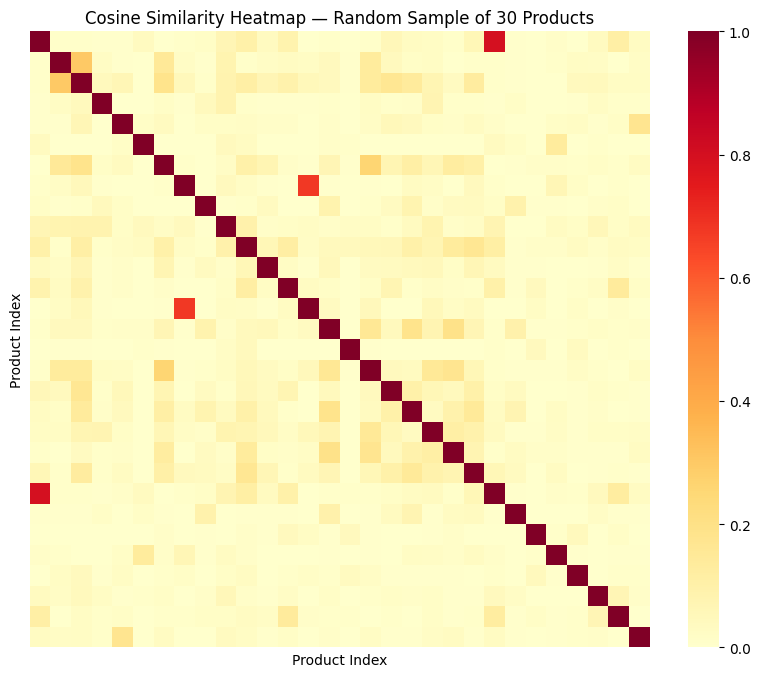

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sample_size = 30
sample_indices = np.random.RandomState(42).choice(tfidf_matrix.shape[0], sample_size, replace=False)
sample_matrix = tfidf_matrix[sample_indices]
sample_similarity = cosine_similarity(sample_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(sample_similarity, cmap="YlOrRd", xticklabels=False, yticklabels=False)
plt.title(f"Cosine Similarity Heatmap — Random Sample of {sample_size} Products")
plt.xlabel("Product Index")
plt.ylabel("Product Index")
plt.show()


**H.2 PCA visualization of TF-IDF vectors (2D projection)**

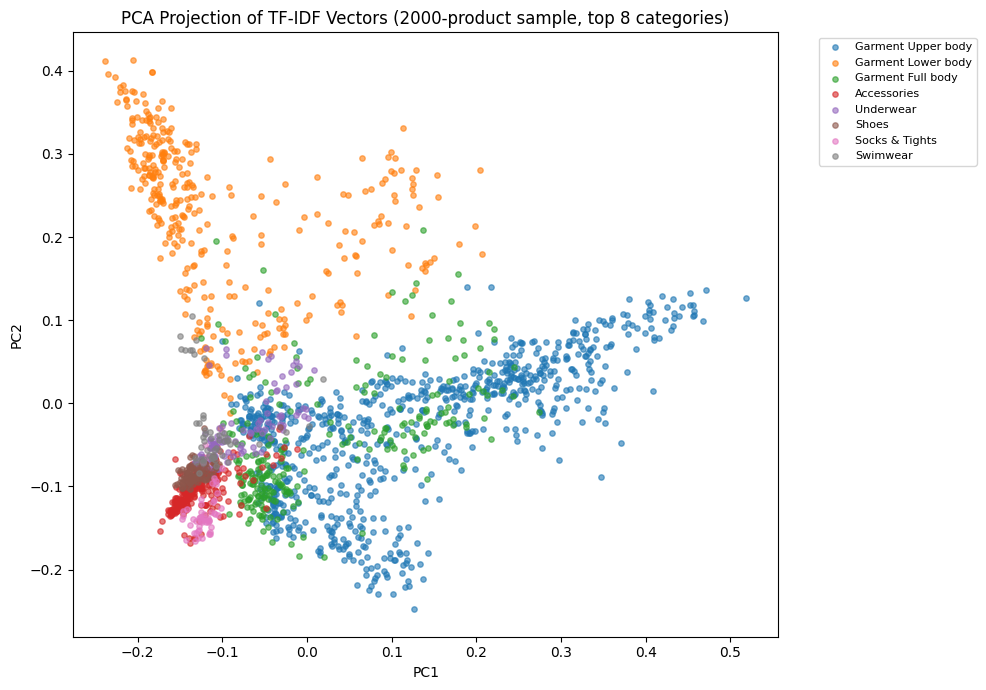

Variance explained by 2 components: 4.2%


In [16]:
from sklearn.decomposition import PCA

pca_sample_size = 2000
pca_indices = np.random.RandomState(42).choice(tfidf_matrix.shape[0], pca_sample_size, replace=False)
pca_sample = tfidf_matrix[pca_indices].toarray()

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(pca_sample)

# Color by product category for visual interpretability
sample_categories = processed_articles.iloc[pca_indices]["product_group_name"].values

plt.figure(figsize=(10, 7))
categories_unique = pd.Series(sample_categories).value_counts().head(8).index
for cat in categories_unique:
    mask = sample_categories == cat
    plt.scatter(pca_result[mask, 0], pca_result[mask, 1], label=cat, alpha=0.6, s=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.title("PCA Projection of TF-IDF Vectors (2000-product sample, top 8 categories)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")


**Why PCA here shows loose, overlapping clusters rather than tight separation:** TF-IDF
vectors are high-dimensional (10,000 features) and PCA is a *linear* projection — squeezing that
into 2D necessarily loses most structure. The categories that do show visible separation are
ones with distinctive vocabulary (e.g., "Shoes" vs. "Underwear"); categories with overlapping
language (e.g., different types of tops) will blend together more.


**H.3 t-SNE visualization (captures non-linear structure PCA misses)**

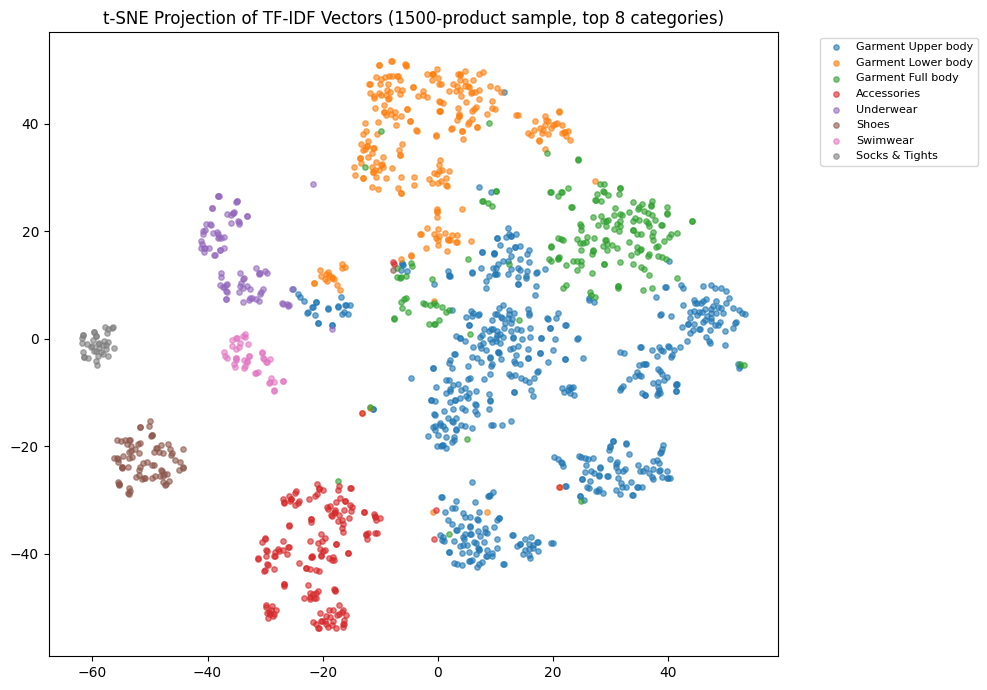

In [17]:
from sklearn.manifold import TSNE

tsne_sample_size = 1500
tsne_indices = np.random.RandomState(42).choice(tfidf_matrix.shape[0], tsne_sample_size, replace=False)
tsne_sample = tfidf_matrix[tsne_indices].toarray()

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca")
tsne_result = tsne.fit_transform(tsne_sample)

sample_categories_tsne = processed_articles.iloc[tsne_indices]["product_group_name"].values

plt.figure(figsize=(10, 7))
categories_unique = pd.Series(sample_categories_tsne).value_counts().head(8).index
for cat in categories_unique:
    mask = sample_categories_tsne == cat
    plt.scatter(tsne_result[mask, 0], tsne_result[mask, 1], label=cat, alpha=0.6, s=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.title("t-SNE Projection of TF-IDF Vectors (1500-product sample, top 8 categories)")
plt.tight_layout()
plt.show()


**Why t-SNE typically shows tighter, more separated clusters than PCA:** t-SNE preserves
local neighborhood structure (which points are close to which) rather than global linear
variance, so it's better at revealing natural groupings in high-dimensional text data — at the
cost of being slower and not preserving true global distances (cluster *sizes* and *distances
between clusters* in a t-SNE plot aren't meaningful, only relative groupings are).


**H.4 Distribution of cosine similarities (sampled pairs, not the full matrix)**

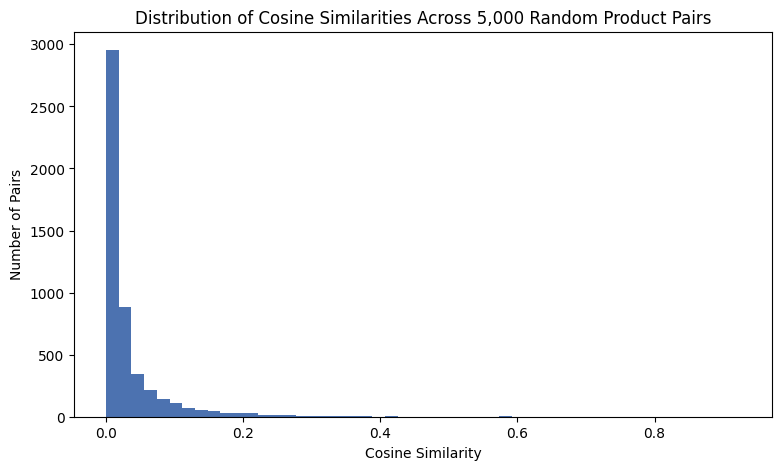

Mean pairwise similarity: 0.0319
Median: 0.0130


In [18]:
n_pairs = 5000
rng = np.random.RandomState(42)
idx_a = rng.choice(tfidf_matrix.shape[0], n_pairs)
idx_b = rng.choice(tfidf_matrix.shape[0], n_pairs)

pair_similarities = np.array([
    cosine_similarity(tfidf_matrix[a], tfidf_matrix[b])[0, 0]
    for a, b in zip(idx_a, idx_b)
])

plt.figure(figsize=(9, 5))
plt.hist(pair_similarities, bins=50, color="#4C72B0")
plt.title(f"Distribution of Cosine Similarities Across {n_pairs:,} Random Product Pairs")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Pairs")
plt.show()

print(f"Mean pairwise similarity: {pair_similarities.mean():.4f}")
print(f"Median: {np.median(pair_similarities):.4f}")


**What this tells us:** most random product pairs across the whole catalog have low
similarity (as expected — most products are unrelated), with a long right tail representing
genuinely related products. This confirms our TF-IDF space is discriminating meaningfully rather
than collapsing everything into similar vectors.


---
## Part I: Evaluation

Content-based filtering has no ratings to predict, so we can't use RMSE-style metrics. Instead:


**I.1 Manual qualitative evaluation** — inspect whether recommended items genuinely make
sense for a human, done directly via the demonstration functions in Part F/K.

**I.2 Precision@K** — *if* interaction data is available, we can check: for products a customer
actually purchased next, how many appear in the top-K content-based recommendations generated
from their previous purchase? This uses `interaction_dataset.csv`/`test_interactions_encoded.parquet`
purely as an **evaluation reference** — it is not used to train the content-based model itself.


In [19]:
# Optional: load interaction data ONLY for evaluation purposes (not used in the CB model above)
interaction_path = os.path.join(PROCESSED_DATA_DIR, "interaction_dataset.csv")

if os.path.exists(interaction_path):
    interactions_eval = pd.read_csv(interaction_path)
    print("Loaded interaction data for evaluation:", interactions_eval.shape)
else:
    interactions_eval = None
    print("Interaction data not found — skipping Precision@K, Coverage, Novelty (Diversity still runs).")


Loaded interaction data for evaluation: (27306439, 8)


In [20]:
def precision_at_k(interactions_eval, k=10, n_customers_sample=200):
    """For a sample of customers with >=2 purchases: use their earliest purchase as the
    'seed' product, generate top-K content-based recommendations, and check what fraction
    of their OTHER actual purchases appear in that list."""
    if interactions_eval is None:
        return None

    customer_counts = interactions_eval["customer_id"].value_counts()
    eligible_customers = customer_counts[customer_counts >= 2].index
    sample_customers = pd.Series(eligible_customers).sample(
        min(n_customers_sample, len(eligible_customers)), random_state=42
    )

    precisions = []
    for cust in sample_customers:
        cust_items = interactions_eval[interactions_eval["customer_id"] == cust]["article_id"].tolist()
        seed_item, actual_next_items = cust_items[0], set(cust_items[1:])

        if seed_item not in id_to_index:
            continue

        try:
            recs = recommend_similar_products(seed_item, top_n=k)
        except ValueError:
            continue

        recommended_ids = set(recs["article_id"].tolist())
        hits = len(recommended_ids & actual_next_items)
        precisions.append(hits / k)

    return np.mean(precisions) if precisions else None

precision_score = precision_at_k(interactions_eval, k=10, n_customers_sample=200)
if precision_score is not None:
    print(f"Precision@10 (content-based, sampled): {precision_score:.4f}")
    print("Note: content-based Precision@K is typically LOW compared to collaborative filtering —")
    print("this is expected, since a purchase driven by trends/social proof/browsing behavior")
    print("won't necessarily be 'content-similar' to a customer's past purchase. This number is")
    print("a baseline to compare against once collaborative filtering is built in Notebook 05.")


Precision@10 (content-based, sampled): 0.0140
Note: content-based Precision@K is typically LOW compared to collaborative filtering —
this is expected, since a purchase driven by trends/social proof/browsing behavior
won't necessarily be 'content-similar' to a customer's past purchase. This number is
a baseline to compare against once collaborative filtering is built in Notebook 05.


**I.3 Coverage** — what fraction of the entire catalog ever gets recommended, across a sample of seed products?

In [21]:
def compute_coverage(n_seed_products=500, k=10):
    sample_indices = np.random.RandomState(42).choice(len(article_ids), n_seed_products, replace=False)
    recommended_ids = set()

    for idx in sample_indices:
        seed_id = article_ids[idx]
        recs = recommend_similar_products(seed_id, top_n=k)
        recommended_ids.update(recs["article_id"].tolist())

    coverage_pct = len(recommended_ids) / len(article_ids) * 100
    return coverage_pct, len(recommended_ids)

coverage_pct, n_unique_recommended = compute_coverage(n_seed_products=500, k=10)
print(f"Catalog coverage from 500 seed products (top-10 each): {coverage_pct:.2f}% "
      f"({n_unique_recommended:,} unique products recommended)")


Catalog coverage from 500 seed products (top-10 each): 4.60% (4,855 unique products recommended)


**I.4 Diversity** — how different are the items within a single recommendation list from each other?

In [22]:
def compute_diversity(product_id, top_n=10):
    """Average pairwise dissimilarity (1 - cosine similarity) among the recommended items
    themselves. Low diversity = recommendations are all near-duplicates of each other."""
    recs = recommend_similar_products(product_id, top_n=top_n)
    rec_indices = [id_to_index[aid] for aid in recs["article_id"]]

    if len(rec_indices) < 2:
        return None

    rec_vectors = tfidf_matrix[rec_indices]
    sim_matrix = cosine_similarity(rec_vectors)

    # Exclude the diagonal (self-similarity = 1) when averaging
    n = sim_matrix.shape[0]
    off_diagonal_sum = sim_matrix.sum() - np.trace(sim_matrix)
    avg_similarity = off_diagonal_sum / (n * (n - 1))

    return 1 - avg_similarity  # diversity = 1 - average similarity

diversity_score = compute_diversity(sample_id, top_n=10)
print(f"Diversity score for sample product's top-10 recommendations: {diversity_score:.4f}")
print("(0 = all recommendations identical, 1 = maximally different)")


Diversity score for sample product's top-10 recommendations: 0.3203
(0 = all recommendations identical, 1 = maximally different)


**I.5 Novelty** — are we recommending popular/obvious items, or genuinely useful less-obvious ones?

In [23]:
def compute_novelty(product_id, interactions_eval, top_n=10):
    """Novelty here is measured as the inverse popularity of recommended items —
    recommending only bestsellers scores LOW novelty; surfacing genuinely relevant but
    less-obvious items scores HIGH novelty."""
    if interactions_eval is None:
        return None

    popularity = interactions_eval["article_id"].value_counts()
    max_popularity = popularity.max()

    recs = recommend_similar_products(product_id, top_n=top_n)
    novelty_scores = [
        1 - (popularity.get(aid, 0) / max_popularity) for aid in recs["article_id"]
    ]
    return np.mean(novelty_scores)

novelty_score = compute_novelty(sample_id, interactions_eval, top_n=10)
if novelty_score is not None:
    print(f"Novelty score for sample product's top-10 recommendations: {novelty_score:.4f}")
    print("(closer to 1 = recommending less-obvious items; closer to 0 = recommending bestsellers)")


Novelty score for sample product's top-10 recommendations: 0.9097
(closer to 1 = recommending less-obvious items; closer to 0 = recommending bestsellers)


---
## Part J: Save Artifacts

`tfidf_vectorizer.pkl` and `tfidf_matrix.npz` were already saved in Part D. We add two more
artifacts here for later notebooks (hybrid combination in particular).


In [24]:
# content_based_model.pkl: bundles everything needed to regenerate recommendations
# without re-fitting TF-IDF from scratch in a later notebook
content_based_model = {
    "tfidf_config": FINAL_TFIDF_CONFIG,
    "article_ids": article_ids,
    "id_to_index": id_to_index,
}
with open("cb_artifacts/content_based_model.pkl", "wb") as f:
    pickle.dump(content_based_model, f)

# similarity_metadata.pkl: lightweight metadata used to interpret similarity scores downstream
# (e.g., in the hybrid notebook, to know which article_id maps to which matrix row)
similarity_metadata = {
    "n_products": len(article_ids),
    "vocab_size": vocab_size,
    "matrix_density_pct": density * 100,
    "coverage_pct": coverage_pct,
}
with open("cb_artifacts/similarity_metadata.pkl", "wb") as f:
    pickle.dump(similarity_metadata, f)

print("Saved: cb_artifacts/content_based_model.pkl")
print("Saved: cb_artifacts/similarity_metadata.pkl")
print("\nAll Notebook 04 artifacts:")
for f in sorted(os.listdir("cb_artifacts")):
    print(" -", f)


Saved: cb_artifacts/content_based_model.pkl
Saved: cb_artifacts/similarity_metadata.pkl

All Notebook 04 artifacts:
 - content_based_model.pkl
 - similarity_metadata.pkl
 - tfidf_matrix.npz
 - tfidf_vectorizer.pkl


**What each artifact is for:**

| File | Purpose in later notebooks |
|---|---|
| `tfidf_vectorizer.pkl` | Fitted vectorizer — reused to vectorize any new/updated product text without refitting |
| `tfidf_matrix.npz` | The full TF-IDF matrix — reused directly for on-demand similarity computation in the hybrid notebook |
| `content_based_model.pkl` | article_id ↔ matrix-index mapping + config — lets the hybrid notebook look up any product's content-based vector without redoing Parts B-D |
| `similarity_metadata.pkl` | Summary stats (coverage, density) — useful for the hybrid notebook's documentation/reporting, and for sanity-checking that the artifacts loaded correctly |


---
## Part K: Demonstration


In [25]:
def demo_recommendation(category_keyword, top_n=5):
    """Find a sample product matching a category keyword, then show its top-N recommendations
    with explanations — a full input -> output -> explanation walkthrough."""
    matches = processed_articles[
        processed_articles["product_type_name"].str.contains(category_keyword, case=False, na=False) |
        processed_articles["product_group_name"].str.contains(category_keyword, case=False, na=False)
    ]
    if matches.empty:
        print(f"No sample product found for keyword: {category_keyword}")
        return

    sample = matches.iloc[0]
    input_id = sample["article_id"]

    print("="*70)
    print(f"INPUT PRODUCT: {sample['prod_name']} (article_id={input_id})")
    print(f"Category: {sample['product_group_name']} | Department: {sample['department_name']}")
    print("="*70)

    recs = recommend_similar_products(input_id, top_n=top_n)
    print(f"\nTOP {top_n} RECOMMENDATIONS:")
    display(recs)

    print("\nEXPLANATIONS:")
    for _, row in recs.iterrows():
        reasons = explain_recommendation(input_id, row["article_id"])
        print(f"\n-> {row['product_name']} (score={row['similarity_score']})")
        for reason in reasons:
            print(f"   - {reason}")

# Demonstrate across four different product types
for keyword in ["Dress", "Shirt", "Shoe", "Bag"]:
    demo_recommendation(keyword, top_n=5)
    print("\n\n")


INPUT PRODUCT: Knit dress (article_id=192460006)
Category: Garment Full body | Department: Tops Knitwear DS

TOP 5 RECOMMENDATIONS:


,article_id,product_name,similarity_score,category,department,colour
0,653750001,Donna Dress,0.5870,Garment Full body,Knitwear,Dark Grey
1,688474004,Sevilla Dress,0.5757,Garment Full body,Tops Knitwear DS,Dark Pink
2,515042002,Lava Jumper,0.5430,Garment Upper body,Tops Knitwear DS,Dark Grey
3,836267001,Balett dress,0.5193,Garment Full body,Knitwear,Black
4,577025001,Hairy Dress,0.5027,Garment Full body,Tops Knitwear DS,Dark Red



EXPLANATIONS:

-> Donna Dress (score=0.587)
   - Same category (Garment Full body)
   - Same colour (Dark Grey)
   - Similar description keywords: dress, knitwear, grey short, neckline long, knitwear dark

-> Sevilla Dress (score=0.5757)
   - Same category (Garment Full body)
   - Same department (Tops Knitwear DS)
   - Similar description keywords: dress, knitwear ds, ds knitwear, knitwear, ds

-> Lava Jumper (score=0.543)
   - Same department (Tops Knitwear DS)
   - Same colour (Dark Grey)
   - Similar description keywords: knitwear ds, ds knitwear, knitwear, ds, tops knitwear

-> Balett dress (score=0.5193)
   - Same category (Garment Full body)
   - Similar description keywords: dress, knitwear, sleeves unlined, neckline long, knit

-> Hairy Dress (score=0.5027)
   - Same category (Garment Full body)
   - Same department (Tops Knitwear DS)
   - Similar description keywords: dress, knitwear ds, ds knitwear, knitwear, ds



INPUT PRODUCT: Nora tee (article_id=189955076)
Category: Ga

,article_id,product_name,similarity_score,category,department,colour
0,554598080,Nora T-shirt,0.6355,Garment Upper body,Jersey Basic,Light Blue
1,554598026,Nora T-shirt,0.6355,Garment Upper body,Jersey Basic,Light Blue
2,659132006,ED Nora tee,0.6100,Garment Upper body,Jersey,Dark Blue
3,630438002,Lily,0.6071,Garment Upper body,Jersey Basic,Black
4,659132009,ED Nora tee,0.6055,Garment Upper body,Jersey,White



EXPLANATIONS:

-> Nora T-shirt (score=0.6355)
   - Same category (Garment Upper body)
   - Same department (Jersey Basic)
   - Same colour (Light Blue)
   - Similar description keywords: nora, jersey basic, ups rounded, basic, jersey

-> Nora T-shirt (score=0.6355)
   - Same category (Garment Upper body)
   - Same department (Jersey Basic)
   - Same colour (Light Blue)
   - Similar description keywords: nora, jersey basic, ups rounded, basic, jersey

-> ED Nora tee (score=0.61)
   - Same category (Garment Upper body)
   - Similar description keywords: nora, ups rounded, soft slub, slub jersey, jersey

-> Lily (score=0.6071)
   - Same category (Garment Upper body)
   - Same department (Jersey Basic)
   - Similar description keywords: pocket short, jersey basic, soft slub, basic, slub jersey

-> ED Nora tee (score=0.6055)
   - Same category (Garment Upper body)
   - Similar description keywords: nora, ups rounded, soft slub, slub jersey, jersey



INPUT PRODUCT: Eva chelsea boot (articl

,article_id,product_name,similarity_score,category,department,colour
0,647338016,Kobe Chelsea Boot,0.7122,Shoes,Shoes,Yellowish Brown
1,647338002,Kobe Chelsea Boot,0.7122,Shoes,Shoes,Yellowish Brown
2,658495003,Carolina Chelsea boot.,0.6779,Shoes,Divided Shoes,Light Beige
3,658495004,Carolina Chelsea boot.,0.6722,Shoes,Divided Shoes,Black
4,658495001,Carolina Chelsea boot.,0.6722,Shoes,Divided Shoes,Black



EXPLANATIONS:

-> Kobe Chelsea Boot (score=0.7122)
   - Same category (Shoes)
   - Same colour (Yellowish Brown)
   - Similar description keywords: chelsea, shoes, boots, chelsea boot, chelsea boots

-> Kobe Chelsea Boot (score=0.7122)
   - Same category (Shoes)
   - Same colour (Yellowish Brown)
   - Similar description keywords: chelsea, shoes, boots, chelsea boot, chelsea boots

-> Carolina Chelsea boot. (score=0.6779)
   - Same category (Shoes)
   - Same department (Divided Shoes)
   - Similar description keywords: chelsea, shoes, boots, chelsea boot, chelsea boots

-> Carolina Chelsea boot. (score=0.6722)
   - Same category (Shoes)
   - Same department (Divided Shoes)
   - Similar description keywords: chelsea, shoes, boots, chelsea boot, chelsea boots

-> Carolina Chelsea boot. (score=0.6722)
   - Same category (Shoes)
   - Same department (Divided Shoes)
   - Similar description keywords: chelsea, shoes, boots, chelsea boot, chelsea boots



INPUT PRODUCT: Sleep bag padded (art

,article_id,product_name,similarity_score,category,department,colour
0,176550020,Sleep bag padded,1.0000,Underwear/nightwear,Baby Nightwear,Dark Blue
1,176550021,Sleep bag padded,0.9806,Underwear/nightwear,Baby Nightwear,White
2,176550018,Sleep bag padded,0.9806,Underwear/nightwear,Baby Nightwear,Off White
3,176550017,Sleep bag padded,0.9788,Underwear/nightwear,Baby Nightwear,Light Pink
4,487937004,Sleep Bag Thin,0.8882,Underwear/nightwear,Baby Nightwear,White



EXPLANATIONS:

-> Sleep bag padded (score=1.0)
   - Same category (Underwear/nightwear)
   - Same department (Baby Nightwear)
   - Same colour (Dark Blue)
   - Similar description keywords: sleep bag, sleep, bag, padded sleep, nightwear

-> Sleep bag padded (score=0.9806)
   - Same category (Underwear/nightwear)
   - Same department (Baby Nightwear)
   - Similar description keywords: sleep bag, sleep, bag, padded sleep, nightwear

-> Sleep bag padded (score=0.9806)
   - Same category (Underwear/nightwear)
   - Same department (Baby Nightwear)
   - Similar description keywords: sleep bag, sleep, bag, padded sleep, nightwear

-> Sleep bag padded (score=0.9788)
   - Same category (Underwear/nightwear)
   - Same department (Baby Nightwear)
   - Similar description keywords: sleep bag, sleep, bag, padded sleep, nightwear

-> Sleep Bag Thin (score=0.8882)
   - Same category (Underwear/nightwear)
   - Same department (Baby Nightwear)
   - Similar description keywords: sleep bag, sleep, bag, 

---
## Part L: Business Discussion

**How Amazon uses content-based filtering:** Amazon's "customers who bought this also viewed"
is largely collaborative, but features like "related to items you've viewed" and new-product
surfacing lean heavily on content-based signals (category, brand, description) — especially for
newly listed products with no purchase history yet, and for populating category/browse pages
where there's no single "seed" user interaction to build off of.

**Why content-based filtering alone is insufficient:**
- It can't detect that people who buy phone cases also tend to buy screen protectors — these
  are content-unrelated but behaviorally linked purchases, invisible to a system that only
  looks at text/category similarity.
- It tends toward narrow, over-similar recommendations (a customer who bought one black dress
  gets shown ten more black dresses, potentially missing what they'd actually respond to based
  on behavior).
- It can't personalize beyond a single seed item's content — it has no concept of a customer's
  broader taste profile across dissimilar categories.

**What problems it cannot solve:**
- Cross-category recommendations driven by co-purchase behavior, not content similarity
- Discovering trending or seasonally popular items regardless of a customer's past content preferences
- Personalizing based on a customer's *aggregate* behavior pattern rather than one item at a time

**How collaborative filtering solves these:** by learning directly from the interaction matrix
(`interaction_matrix.npz`, already built in Step 3), collaborative filtering can surface
non-obvious, behaviorally-linked recommendations purely from co-purchase patterns — no text or
category matching required. This is precisely the missing half of the system, and it's what
Notebook 05 builds next.


---
## Deliverable Summary

- Built a complete content-based recommendation engine: TF-IDF vectorization of product text,
  on-demand cosine similarity (full matrix avoided due to infeasible memory cost), reusable
  recommendation functions, explainability, visualizations, and evaluation metrics
  (Precision@K, Coverage, Diversity, Novelty).
- Saved 4 reusable artifacts under `cb_artifacts/`: `tfidf_vectorizer.pkl`, `tfidf_matrix.npz`,
  `content_based_model.pkl`, `similarity_metadata.pkl`.
- **No collaborative filtering or hybrid logic was implemented in this notebook.**

**What's next — Notebook 05: Collaborative Filtering**
Notebook 05 will use `interaction_matrix.npz` and `label_encoders.pkl` (from Step 3) to build a
matrix factorization model (ALS-style, suited to large sparse implicit feedback data), evaluated
using the same time-based train/test split already saved. That model will capture the
behavioral, non-content-based patterns this notebook cannot — setting up the final hybrid
blend in the notebook after that.
